# Explore instances and labels

This notebook focuses on the object-level view of the dataset. We use `objects.csv`, where each row corresponds to one annotated instance. 

The main questions are:

- Instaces distribution across cities and splits
- Where in the image do objects usually appear?
- Which german cities can we use to compare the perfomacne of zürich? So that we can be sure that the performance difference is not due to label distribution differences?
- Scmall vs large objects, how are they distributed across cities and splits? 


## Preparation

Before running the notebook, we created a `data/objects.csv` file by running inside the slurm server:


```bash
scripts\summarize_objects.sh
```

The script collects all the box and instance labels from the `data/instances` folder and saves them in a single CSV file. This allows us to analyze the distribution of object labels across the dataset per city and per class.

In [27]:
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# load the object-level table (one row = one annotated instance)
objects_path = Path("../data/objects.csv")
if not objects_path.exists():
    objects_path = Path("data/objects.csv")

objects_df = pd.read_csv(objects_path)


# bin the bounding-box center into 5 bands, used later for the spatial view
bin_labels = ["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]
objects_df["bbox_x_bin"] = pd.cut(
    objects_df["bbox_xc"], bins=np.linspace(0, 1, 6), labels=bin_labels, include_lowest=True
)
objects_df["bbox_y_bin"] = pd.cut(
    objects_df["bbox_yc"], bins=np.linspace(0, 1, 6), labels=bin_labels, include_lowest=True
)

# classes ordered from most to least frequent, so all plots use the same order
class_order = objects_df["class_name"].value_counts().index.tolist()

objects_df.head()


,object_id,class_id,bbox_xc,bbox_yc,bbox_w,bbox_h,seg_area_rel,n_polygon_points,image_filename,image_relpath,split,city,class_name,bbox_area_rel,bbox_aspect_ratio,seg_to_bbox_ratio,bbox_x_bin,bbox_y_bin
0,0,0,0.440429,0.460450,0.009765,0.049805,0.000288,45,aachen_000000_000019_leftImg8bit,images/train/aachen_000000_000019_leftImg8bit.png,train,aachen,person,0.000486,0.196065,0.593167,40-60%,40-60%
1,1,0,0.451416,0.459473,0.009278,0.051758,0.000321,47,aachen_000000_000019_leftImg8bit,images/train/aachen_000000_000019_leftImg8bit.png,train,aachen,person,0.000480,0.179257,0.667788,40-60%,40-60%
2,2,0,0.442383,0.475098,0.004883,0.020508,0.000076,16,aachen_000000_000019_leftImg8bit,images/train/aachen_000000_000019_leftImg8bit.png,train,aachen,person,0.000100,0.238102,0.757051,40-60%,40-60%
3,3,1,0.907715,0.481934,0.027344,0.104492,0.000980,191,aachen_000000_000019_leftImg8bit,images/train/aachen_000000_000019_leftImg8bit.png,train,aachen,rider,0.002857,0.261685,0.342867,80-100%,40-60%
4,4,2,0.978515,0.492675,0.037109,0.032227,0.000969,45,aachen_000000_000019_leftImg8bit,images/train/aachen_000000_000019_leftImg8bit.png,train,aachen,car,0.001196,1.151488,0.810002,80-100%,40-60%


In [28]:
# summary table per class: how many instances and the typical object sizes
class_summary = objects_df.groupby("class_name").agg(
    n_instances=("object_id", "size"),
    median_seg_area_rel=("seg_area_rel", "median"),
    median_bbox_area_rel=("bbox_area_rel", "median"),
    median_seg_to_bbox_ratio=("seg_to_bbox_ratio", "median"),
)

# share of all instances that belong to each class
class_summary["share_of_instances"] = class_summary["n_instances"] / len(objects_df)

# sort by frequency and round for readability
class_summary = class_summary.sort_values("n_instances", ascending=False).round(4)
class_summary


,n_instances,median_seg_area_rel,median_bbox_area_rel,median_seg_to_bbox_ratio,share_of_instances
class_name,,,,,
car,38959,0.0006,0.0010,0.6470,0.4949
person,25694,0.0003,0.0005,0.5711,0.3264
bicycle,7514,0.0003,0.0006,0.5661,0.0955
rider,3077,0.0004,0.0007,0.4873,0.0391
motorcycle,1307,0.0005,0.0008,0.5896,0.0166
bus,846,0.0008,0.0012,0.7365,0.0107
truck,822,0.0008,0.0013,0.7035,0.0104
train,498,0.0008,0.0013,0.7056,0.0063


## Instaces distribution across cities and splits

Total annotated instances per class across the full dataset, ordered from most to least frequent. 

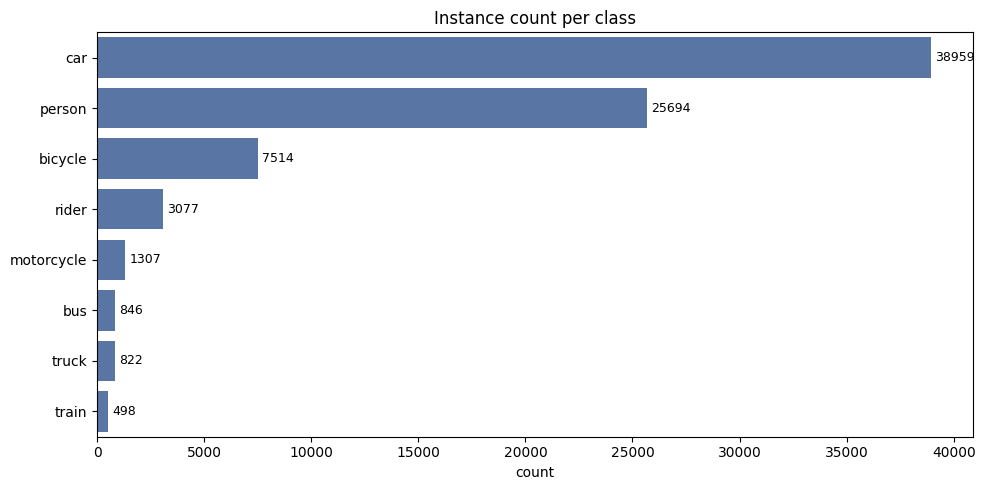

In [ ]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=objects_df, y="class_name", order=class_order)
ax.set_title("Instance count per class")
ax.set_xlabel("count")
ax.set_ylabel("")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=9)

plt.tight_layout()
plt.show()


 The plot makes the class imbalance immediately visible. Car and person dominate, while bus, truck, and train are rare. One need to be carefully chosen the evaluation metrics to avoid misleading results. But one also need to see, that in our case the number of persons and care are perharps overestimated, as we vvcut one single car into multiple instances when a pole is in front of it. While the persons, when there is a group of person wich overlap. As next we break down the Instances by city and colored by train/val/test split, with one panel per class. This shows which cities carry each class and whether any split is short on a given class.

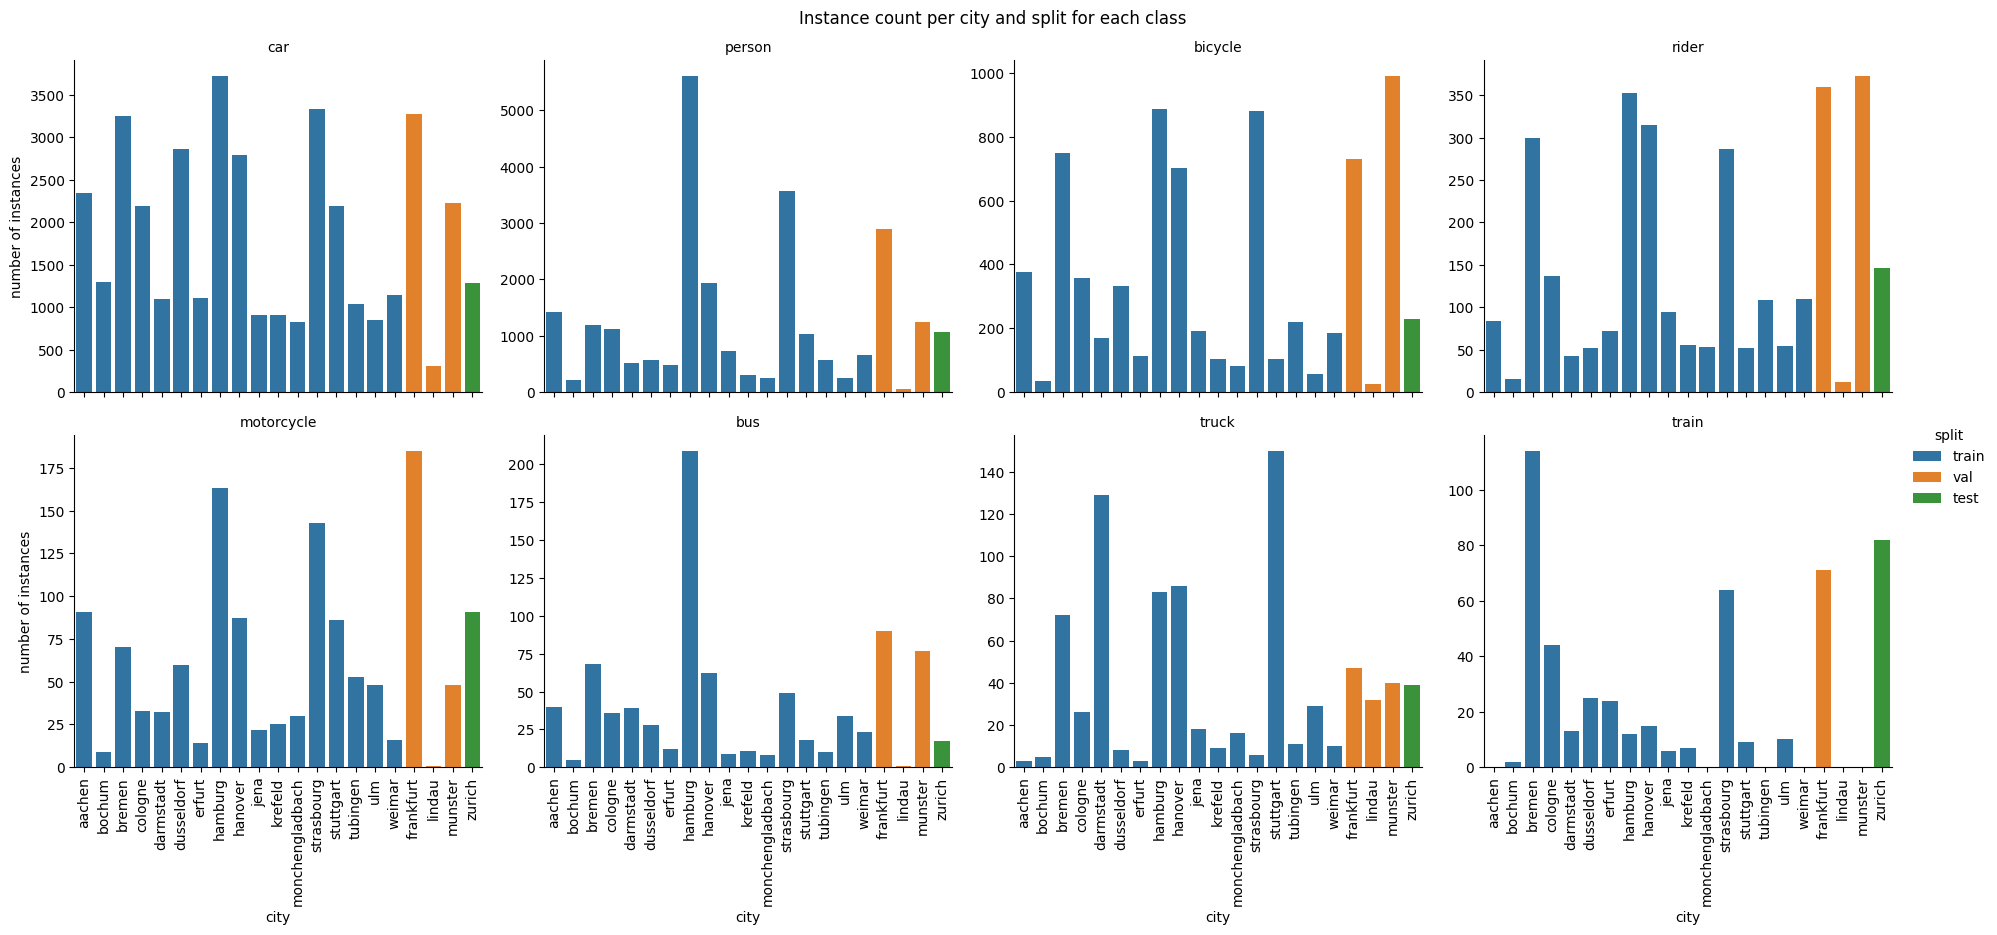

In [30]:
split_order = ["train", "val", "test"]
objects_df["split"] = pd.Categorical(objects_df["split"], categories=split_order, ordered=True)


# instances per city, split by train/val/test, one panel per class
g = sns.catplot(
    data=objects_df,
    x="city",
    hue="split",
    col="class_name",
    col_order=class_order,
    col_wrap=4,
    kind="count",
    height=4,
    aspect=1.2,
    sharey=False,
)

g.set_titles("{col_name}")
g.set_axis_labels("city", "number of instances")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=90)

g.figure.suptitle("Instance count per city and split for each class", y=1.02)
plt.show()


We can observe that the instances count vary a lot across cities, but not all classes are present in all cities. For example, `train` is not present in lindau or aachen. But in generall we can say that each class is avialble in multiple cities and the train/val/test split is not biased towards a specific city with the expactation of the `train` class, which is only present by frankfurt in the validation split. As next we need to search for city that has a similar distribution of classes and instances to zürich for our german vs swiss comparison.

## Similar cities to Zürich

Having looked at how the label distribution varies across cities above, we now make the test-city choice explicit, using two transparent criteria instead of a single weighted score:

1. **Representativeness**: how close a city's class distribution is to zurich's, measured by the cosine similarity of the per-class instance counts (`cos_to_zurich`).
2. **Rare-class robustness** - the minimum number of instances over all classes (`rarest_class_count`). A higher value means the per-class AP of rare classes (`bus`, `truck`, `train`) is estimated on more samples and is therefore less noisy. 

In [35]:
# reference = Zürich's class distribution (the cross-region test city we want to match)
zurich_city = "zurich"
zurich_counts = objects_df[objects_df["city"] == zurich_city]["class_name"].value_counts()
zurich_counts = zurich_counts.reindex(class_order, fill_value=0)
zurich_share = zurich_counts / zurich_counts.sum()


def cosine_similarity(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


# build one summary row per training city
train_cities = sorted(objects_df[objects_df["split"] == "train"]["city"].unique())

rows = []
for city in train_cities:
    counts = objects_df[objects_df["city"] == city]["class_name"].value_counts()
    counts = counts.reindex(class_order, fill_value=0)
    share = counts / counts.sum()
    rows.append({
        "city": city,
        "n_instances": int(counts.sum()),
        "class_coverage": int((counts > 0).sum()),
        "rarest_class_count": int(counts.min()),
        "cos_to_zurich": round(cosine_similarity(share, zurich_share), 4),
    })

candidate_df = pd.DataFrame(rows)

# hard constraint: keep only cities that contain every class
candidate_df = candidate_df[candidate_df["class_coverage"] == len(class_order)]
candidate_df = candidate_df.sort_values("cos_to_zurich", ascending=False).reset_index(drop=True)

# rule: best rare-class coverage among the cities most similar to Zürich (cos >= 0.99)
representative = candidate_df[candidate_df["cos_to_zurich"] >= 0.99]
representative = representative.sort_values("rarest_class_count", ascending=False)
chosen_city = representative.iloc[0]["city"]

print("Cities most similar to Zürich (cos >= 0.99):", list(representative["city"]))
print("Chosen comparison city (best all-rounder):", chosen_city)
candidate_df


Cities most similar to Zürich (cos >= 0.99): ['hanover', 'jena']
Chosen comparison city (best all-rounder): hanover


,city,n_instances,class_coverage,rarest_class_count,cos_to_zurich
0,jena,1973,8,6,0.9979
1,hanover,6003,8,15,0.9929
2,strasbourg,8328,8,6,0.9898
3,cologne,3942,8,26,0.9741
4,darmstadt,2037,8,13,0.9644
5,stuttgart,3646,8,9,0.9607
6,erfurt,1816,8,3,0.9577
7,hamburg,11051,8,12,0.9563
8,bremen,5820,8,68,0.9407
9,krefeld,1419,8,7,0.9288


We decide to use the city of **Cologne** as the in-distribution test city, as it has a high similarity an the rarrest class count is still 26, compared to the more similar cities with only 6 and 15 instances for the rarrest class. For this we use the script "move_cologne.sh" to move the images and annotations to the test split. 

## Appearance of objects in the images

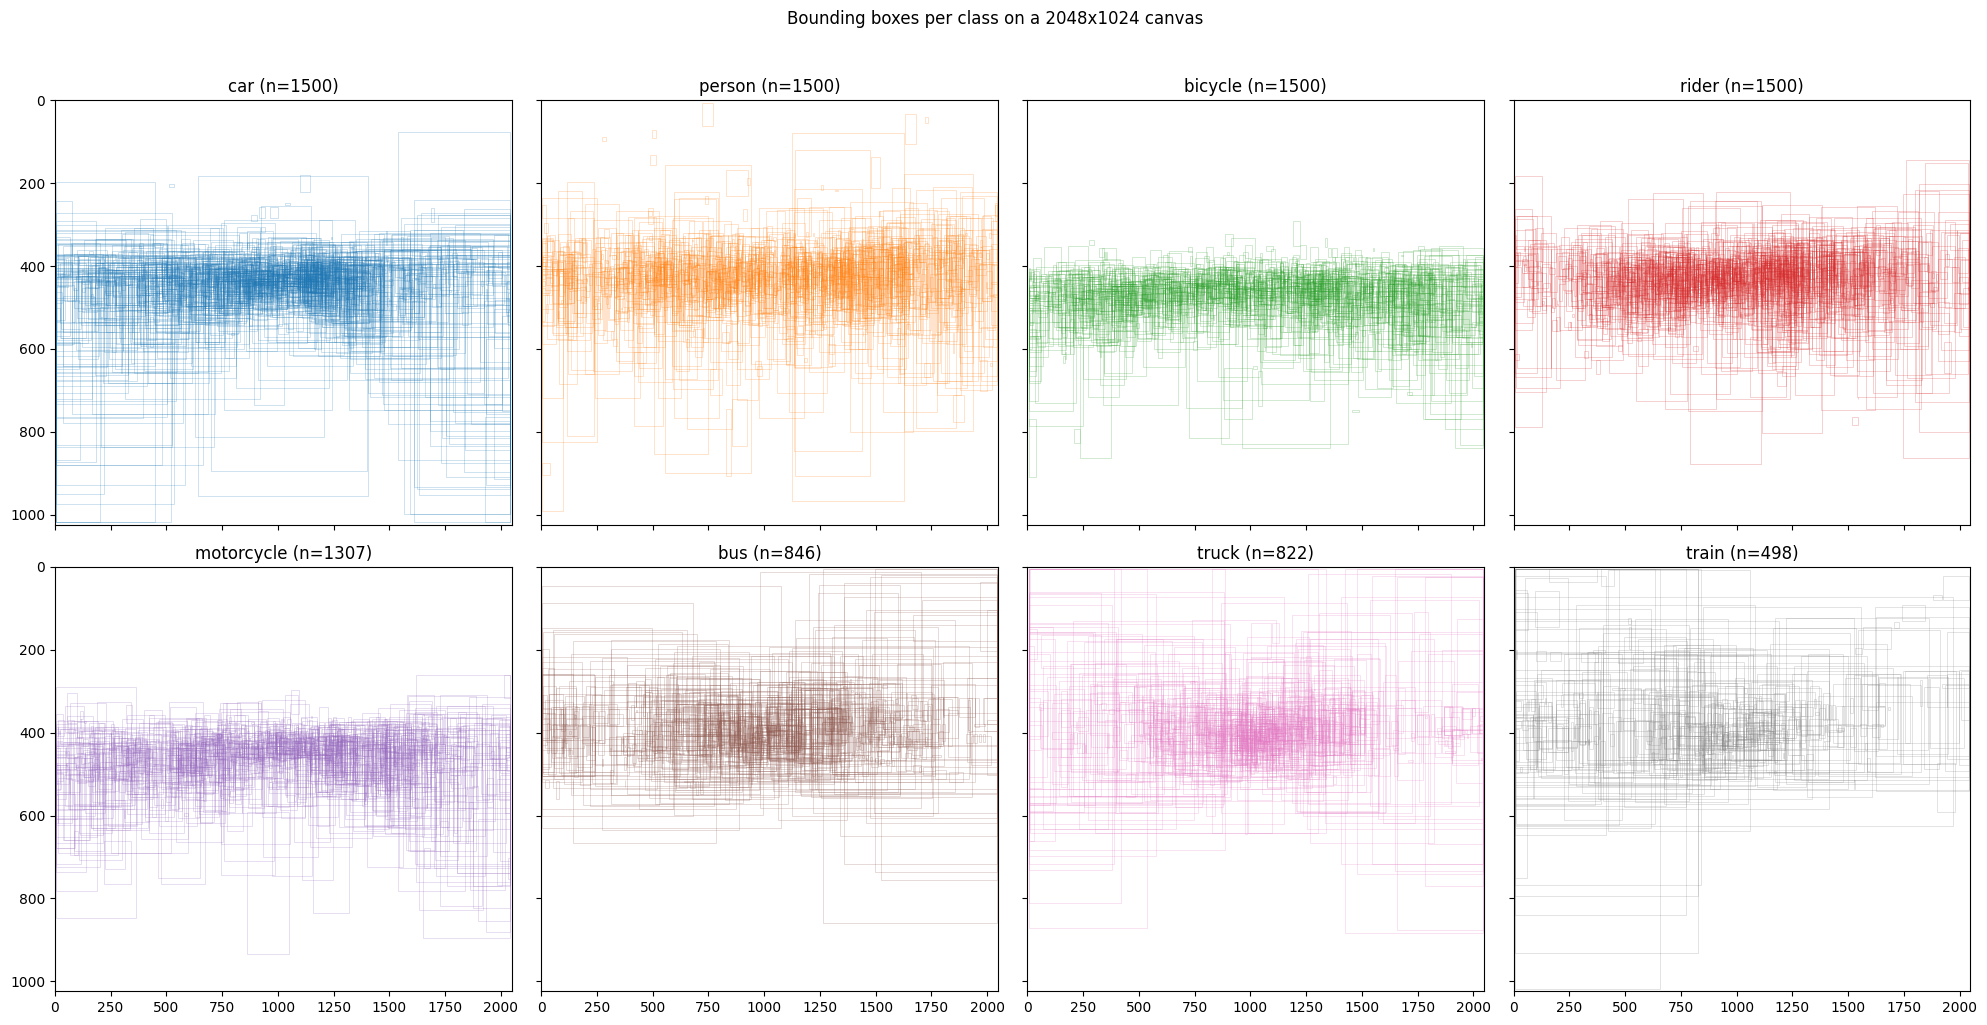

In [31]:
from matplotlib.patches import Rectangle

# draw the bounding boxes of each class on a common 2048x1024 canvas
img_width = 2048
img_height = 1024
max_boxes = 1500  # subsample so the plot does not get too dense

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
axes = axes.ravel()
colors = sns.color_palette("tab10", n_colors=len(class_order))

for ax, class_name, color in zip(axes, class_order, colors):
    class_df = objects_df[objects_df["class_name"] == class_name]
    if len(class_df) > max_boxes:
        class_df = class_df.sample(max_boxes, random_state=42)

    for _, row in class_df.iterrows():
        width = row["bbox_w"] * img_width
        height = row["bbox_h"] * img_height
        x0 = row["bbox_xc"] * img_width - width / 2
        y0 = row["bbox_yc"] * img_height - height / 2
        ax.add_patch(
            Rectangle((x0, y0), width, height, fill=False, edgecolor=color, linewidth=0.5, alpha=0.3)
        )

    ax.set_title(f"{class_name} (n={len(class_df)})")
    ax.set_xlim(0, img_width)
    ax.set_ylim(img_height, 0)  # flip y so (0, 0) is top-left, like an image

fig.suptitle("Bounding boxes per class on a 2048x1024 canvas", y=1.02)
plt.tight_layout()
plt.show()


Up to 1'500 bounding boxes per class drawn on a shared 2048x1024 image canvas. One interesting observation is that the objects are distibuted over a horizontal band in the image, with some boxes appearing way above (as e.g. in persons or car). This may be due the fact that they are images taken from a tunnel or a bridge, where the camera is looking down on the road.

## Small vs large objects

For the instance size we use the segmentation area `seg_area_rel` (the actual mask area), not the bounding-box area, as the true instance size. We split it into four quartile bins (25% steps).

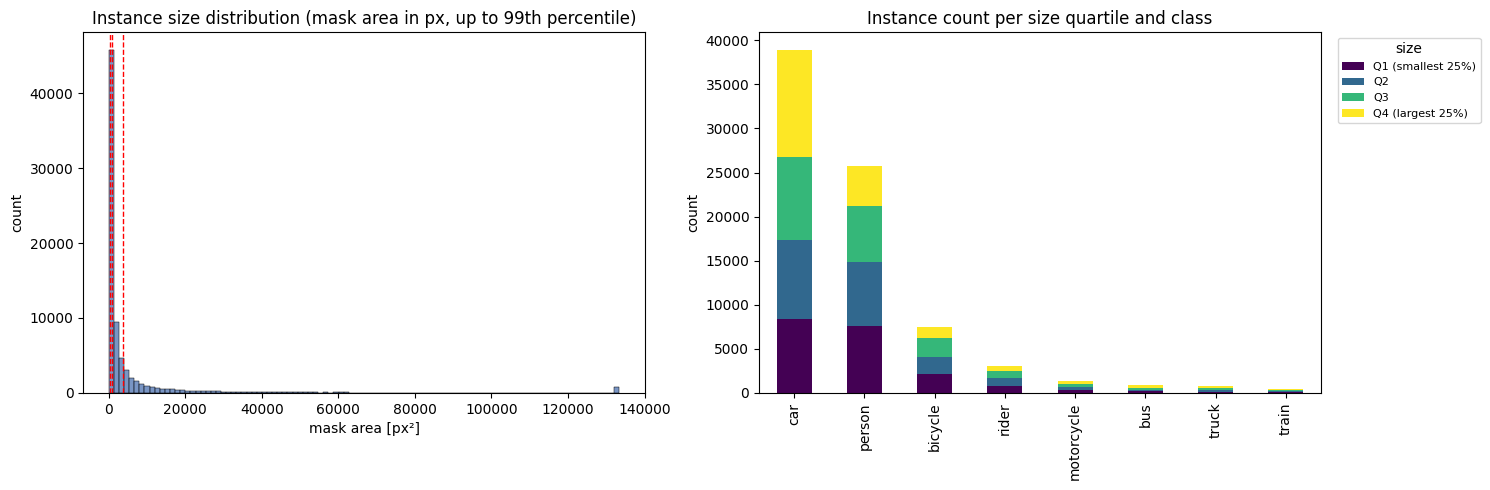

In [39]:
# Cityscapes images are a fixed size, so we can convert the relative area to pixels
IMG_W, IMG_H = 2048, 1024
objects_df["seg_area_px"] = objects_df["seg_area_rel"] * IMG_W * IMG_H
objects_df["seg_side_px"] = np.sqrt(objects_df["seg_area_px"])  # equivalent square edge length

area = objects_df["seg_area_px"].dropna()
quartile_edges = area.quantile([0.0, 0.25, 0.5, 0.75, 1.0]).to_numpy()
size_labels = ["Q1 (smallest 25%)", "Q2", "Q3", "Q4 (largest 25%)"]
objects_df["size_quartile"] = pd.cut(
    objects_df["seg_area_px"], bins=quartile_edges, labels=size_labels, include_lowest=True
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# left: overall size distribution in pixels, with the quartile edges drawn in
x_max = area.quantile(0.99)  # cut off the long tail so the plot stays readable
sns.histplot(area.clip(upper=x_max), bins=100, color="#4C72B0", ax=axes[0])
for edge in quartile_edges[1:-1]:
    axes[0].axvline(edge, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Instance size distribution (mask area in px, up to 99th percentile)")
axes[0].set_xlabel("mask area [px²]")
axes[0].set_ylabel("count")


# right: for each class, the absolute number of instances per size quartile
quartile_counts = pd.crosstab(objects_df["class_name"], objects_df["size_quartile"])
quartile_counts = quartile_counts.reindex(class_order)
quartile_counts.plot(kind="bar", stacked=True, colormap="viridis", ax=axes[1])
axes[1].set_title("Instance count per size quartile and class")
axes[1].set_xlabel("")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=90)
axes[1].legend(title="size", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()



The left plot shows the overall size distribution with the quartile edges drawn in, and the right plot shows, for each class, how its instances spread across the four size quartiles. We can observe that they are a high number of realy small instances, which may be hard to detect and they appear for each class. To get a better understanding of the size distribution we look at them on one actual image. 

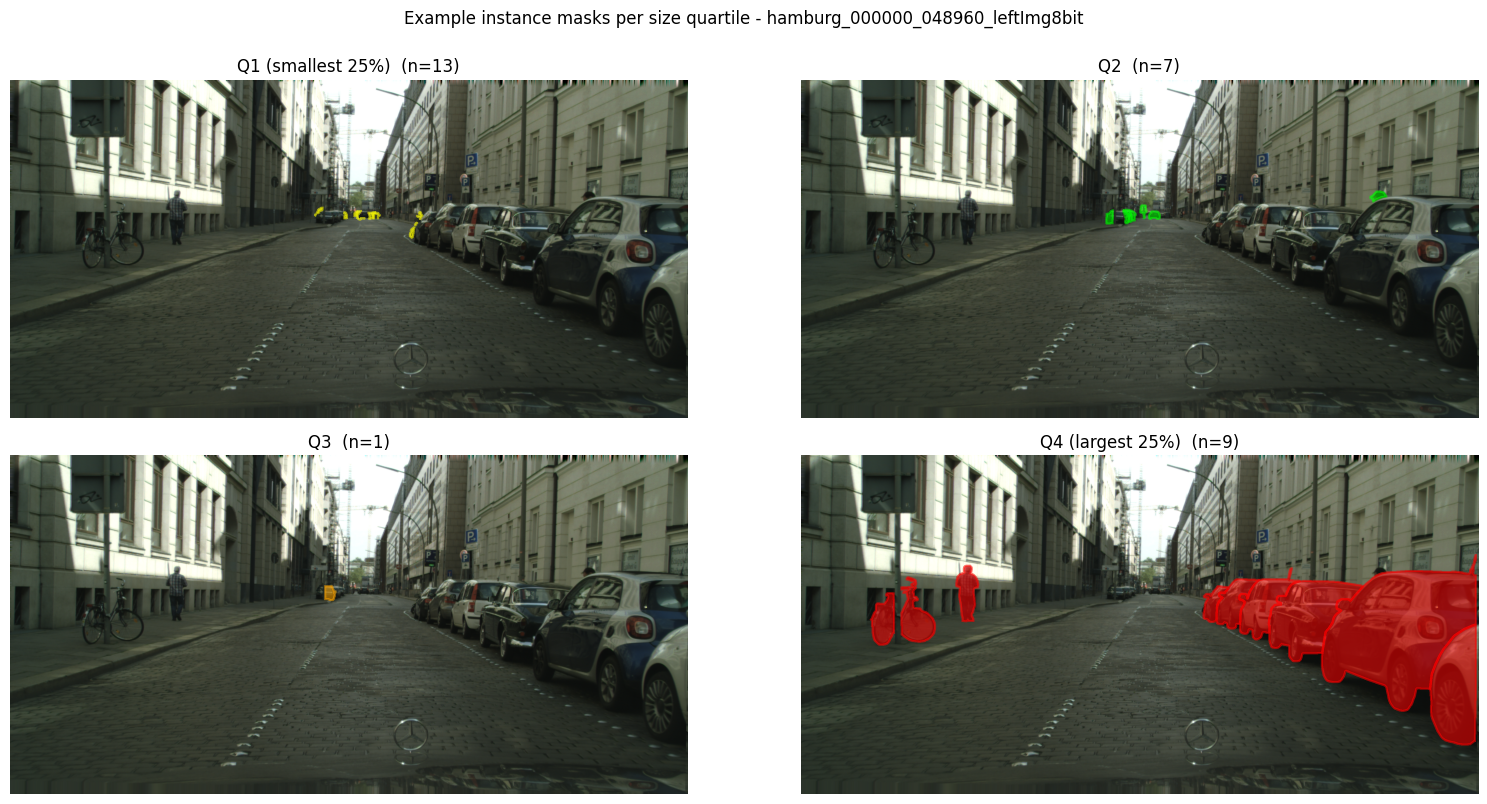

In [34]:
from PIL import Image
from matplotlib.patches import Polygon

img_root = Path("../data/leftImg8bit_trainvaltest/leftImg8bit")
ann_root = Path("../data/yolo_annotations_instances")


def image_path(row):
    return img_root / str(row["split"]) / row["city"] / (row["image_filename"] + ".png")


# exclude test city since the annotations are not public, so we can't show an example from there
candidates = objects_df[objects_df["split"] != "test"]

# pick one image that has an instance in every quartile, with the widest size range
n_quartiles = candidates.groupby("image_filename")["size_quartile"].nunique()
images_with_all = n_quartiles[n_quartiles == 4].index
sizes = candidates[candidates["image_filename"].isin(images_with_all)].groupby("image_filename")["seg_area_rel"]
example_name = (sizes.max() / sizes.min().clip(lower=1e-9)).idxmax()

# rows for this image (same order as the annotation file) and the image itself
example = candidates[candidates["image_filename"] == example_name].sort_values("object_id")
img = Image.open(image_path(example.iloc[0]))
img_width, img_height = img.size

# read the polygon for each instance and convert normalized points to pixel coordinates
ann_lines = (ann_root / (example_name + ".txt")).read_text().strip().splitlines()
instances = []
for (_, row), line in zip(example.iterrows(), ann_lines):
    coords = [float(v) for v in line.split()[1:]]
    points = [(coords[k] * img_width, coords[k + 1] * img_height) for k in range(0, len(coords), 2)]
    instances.append((row["size_quartile"], points))

quartile_colors = {
    "Q1 (smallest 25%)": "yellow",
    "Q2": "lime",
    "Q3": "orange",
    "Q4 (largest 25%)": "red",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, (label, color) in zip(axes.ravel(), quartile_colors.items()):
    ax.imshow(img)
    n = 0
    for quartile, points in instances:
        if quartile == label:
            ax.add_patch(Polygon(points, closed=True, facecolor=color, edgecolor=color, alpha=0.55, linewidth=1.5))
            n += 1
    ax.set_title(f"{label}  (n={n})")
    ax.axis("off")

fig.suptitle(f"Example instance masks per size quartile - {example_name}", y=1.0)
plt.tight_layout()
plt.show()


The same image is shown four times, with each panel highlighting only the instances in one size quartile. The smallest objects Q1 are small and even hard to see and distinguish as human,  while the larger one re directly recognizable as human. Also as observed in the distribution plot, the differnces between q1 and q2 are not that big, which can be seen if we comapre the mask vs the unmaksed in q3 or q4. 


## Conclusion
With this analysis the dataset is ready for training: the split is in place, and using Cologne (in-distribution, similar to Zürich) against Zürich (cross-region) lets us later read the performance gap as a geographic domain shift rather than a label artifact. The two remaining challenges are the class imbalance (rare bus/truck/train → per-class metrics needed) and the many small instances, which are hard to detect.